In [136]:
import pandas as pd
import numpy as np
import matplotlib as mplb
import seaborn as sns
import scypy as sp
pd.set_option('display.max_columns', 500)

In [137]:
users_df = pd.read_csv(
    "users.csv",
    skiprows=1,
    delimiter=";",
    parse_dates=["date_joined"]
)

In [138]:
users_df.head()

,id,username,date_joined
0,416,nsosabisfsobm,2022-01-02 12:22:43
1,43,NbabnnbTona,2021-07-01 09:11:42
2,50,jbdn,2021-08-04 09:01:56
3,249,Kbaoxsnb,2021-11-27 07:03:35
4,77,bxakbasmo$$$,2021-11-09 14:31:46


In [139]:
users_df.dtypes

id                      int64
username               object
date_joined    datetime64[ns]
dtype: object

In [140]:
code_df = pd.read_csv(
    "coderun.csv",
    skiprows=0,
    delimiter=",",
    parse_dates=["created_at"]
)

In [141]:
code_df.head()

,id,created_at,problem_id,user_id,language_id
0,1,2021-04-07 06:06:20,13,10,3
1,2,2021-03-31 07:10:06,15,13,3
2,3,2021-04-04 14:55:26,1,6,3
3,4,2021-03-29 21:24:51,26,4,3
4,5,2021-03-30 11:29:12,21,18,3


In [142]:
code_df.dtypes

id                      int64
created_at     datetime64[ns]
problem_id              int64
user_id                 int64
language_id             int64
dtype: object

In [143]:
df = pd.merge(
    code_df, 
    users_df, 
    how="left",
    left_on="user_id",
    right_on="id",
    suffixes=['_run', '_user']
)
df.head()


,id_run,created_at,problem_id,user_id,language_id,id_user,username,date_joined
0,1,2021-04-07 06:06:20,13,10,3,NaN,NaN,NaT
1,2,2021-03-31 07:10:06,15,13,3,NaN,NaN,NaT
2,3,2021-04-04 14:55:26,1,6,3,NaN,NaN,NaT
3,4,2021-03-29 21:24:51,26,4,3,NaN,NaN,NaT
4,5,2021-03-30 11:29:12,21,18,3,NaN,NaN,NaT


In [144]:
df2 = df.dropna()
df2 = df2[["user_id", "created_at", "date_joined"]].groupby("user_id").agg({
    "created_at":"max",
    "date_joined":"min"
}).reset_index()
df2["diff"] = (df2.created_at - df2.date_joined).dt.days - (df2.created_at - df2.date_joined).dt.days%50
df2.head()


,user_id,created_at,date_joined,diff
0,43,2022-03-24 12:31:27.871,2021-07-01 09:11:42,250
1,50,2022-04-21 09:21:56.419,2021-08-04 09:01:56,250
2,217,2021-12-01 11:03:40.113,2021-11-24 16:05:45,0
3,218,2022-04-09 14:01:26.904,2021-11-24 17:09:58,100
4,219,2022-02-12 08:43:47.419,2021-11-24 17:11:49,50


In [145]:
df3 = df2.groupby("diff")["user_id"].agg("count").to_frame().reset_index().sort_values(by="user_id", ascending=False)
df3.head()

,diff,user_id
0,0,41
2,100,16
1,50,11
3,150,3
4,250,2


In [146]:
users = users_df
code = code_df
code.head()

,id,created_at,problem_id,user_id,language_id
0,1,2021-04-07 06:06:20,13,10,3
1,2,2021-03-31 07:10:06,15,13,3
2,3,2021-04-04 14:55:26,1,6,3
3,4,2021-03-29 21:24:51,26,4,3
4,5,2021-03-30 11:29:12,21,18,3


In [147]:
code.columns = ['id', 'date', 'problem_id', 'user_id', 'language_id']
code.head()

,id,date,problem_id,user_id,language_id
0,1,2021-04-07 06:06:20,13,10,3
1,2,2021-03-31 07:10:06,15,13,3
2,3,2021-04-04 14:55:26,1,6,3
3,4,2021-03-29 21:24:51,26,4,3
4,5,2021-03-30 11:29:12,21,18,3


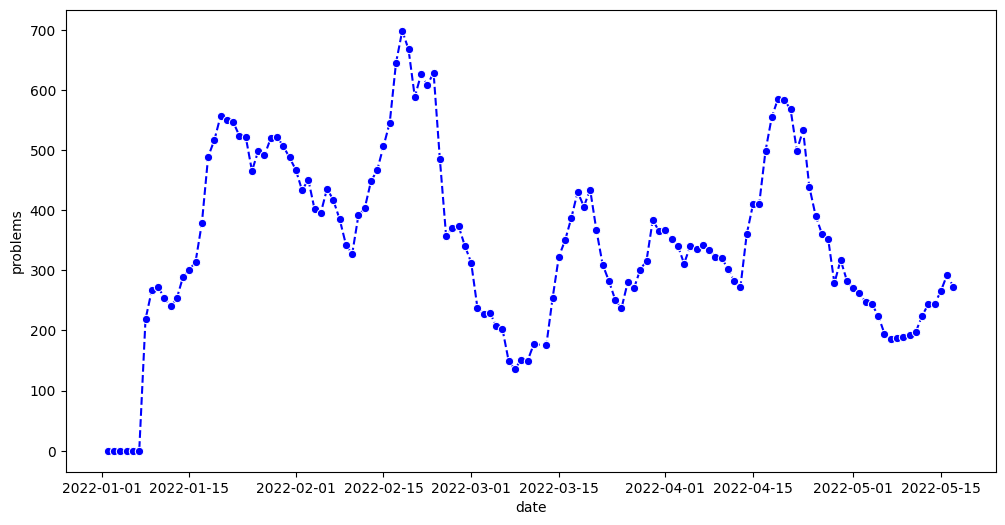

In [148]:
from datetime import date
import matplotlib.pyplot as plt
code['date'] = pd.to_datetime(code['date']).dt.date
df = code[code['date'] > date(2022, 1, 1)].groupby("date").agg({"id": "count"}).reset_index()
df.columns = ["date", "problems"]
df.problems = df.problems.rolling(7).mean().fillna(0).round(2)
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x="date", y="problems", color="blue", linestyle="--", marker="o")
plt.show()

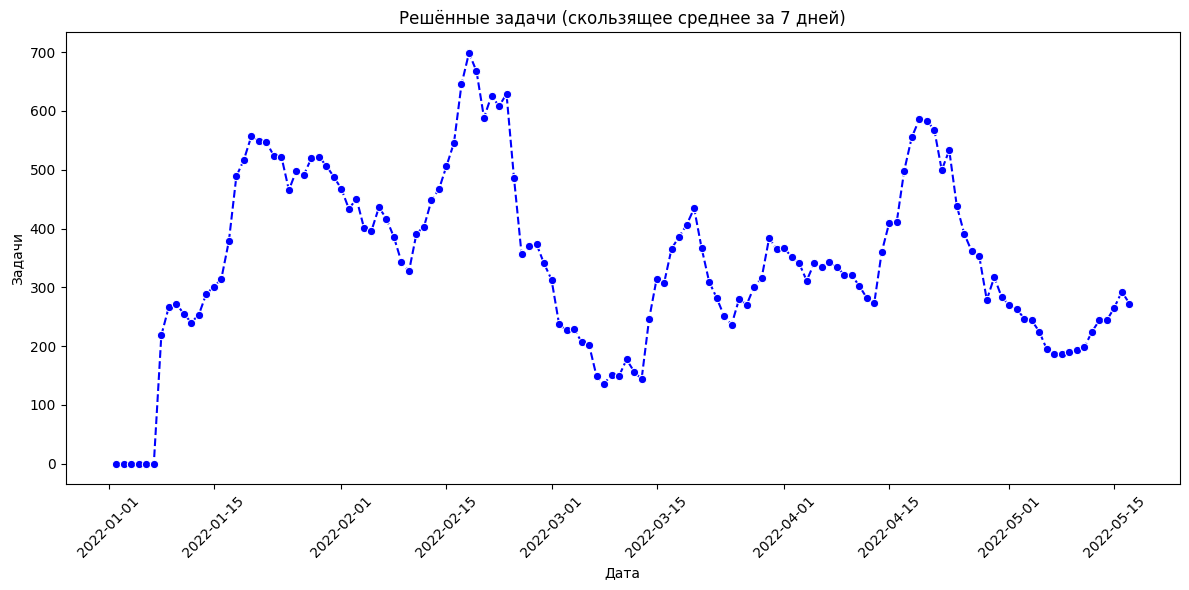

In [149]:
from datetime import date
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


code['date'] = pd.to_datetime(code['date']).dt.date


filtered = code[code['date'] > date(2022, 1, 1)]


df = filtered.groupby("date").agg({"id": "count"}).reset_index()
df.columns = ["date", "problems"]


full_range = pd.DataFrame({
    "date": pd.date_range(start=df["date"].min(), end=df["date"].max()).date
})


df = full_range.merge(df, on="date", how="left")

df["problems"] = df["problems"].fillna(0)


df["problems"] = df["problems"].rolling(7).mean().fillna(0).round(2)

# График
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x="date", y="problems", color="blue", linestyle="--", marker="o")
plt.xticks(rotation=45)
plt.title("Решённые задачи (скользящее среднее за 7 дней)")
plt.xlabel("Дата")
plt.ylabel("Задачи")
plt.tight_layout()
plt.show()

In [150]:
coderun = pd.read_csv(
    "coderun.csv",
    skiprows=0,
    delimiter=",",
    parse_dates=["created_at"]
)

In [151]:
coderun.head()

,id,created_at,problem_id,user_id,language_id
0,1,2021-04-07 06:06:20,13,10,3
1,2,2021-03-31 07:10:06,15,13,3
2,3,2021-04-04 14:55:26,1,6,3
3,4,2021-03-29 21:24:51,26,4,3
4,5,2021-03-30 11:29:12,21,18,3


In [157]:
import csv

f = []
with open('coderun.csv', newline='', encoding='utf-8') as csvfile:
    reader = csv.reader(csvfile)
    for ind, row in enumerate(reader):
        if row != []:
            f.append(row)
df = pd.DataFrame(f[1:], columns=f[0])
df.head()

,id,created_at,problem_id,user_id,language_id
0,1,2021-04-07 06:06:20.000,13,10,3
1,2,2021-03-31 07:10:06.000,15,13,3
2,3,2021-04-04 14:55:26.000,1,6,3
3,4,2021-03-29 21:24:51.000,26,4,3
4,5,2021-03-30 11:29:12.000,21,18,3


In [167]:
coderun = pd.read_csv(
    "coderun.csv",
    skiprows=0,
    delimiter=",",
    parse_dates=["created_at"]
)

coderun["date"] = coderun["created_at"].dt.date
df = coderun.groupby("date").agg({"problem_id":"nunique"}).reset_index()
df.columns = ["date", "problems"]
df["prev_problems"] = df.problems.shift(3)
df.fillna(0, inplace=True)
df["diff"] = df.problems - df.prev_problems
df

,date,problems,prev_problems,diff
0,2021-03-27,1,0.0,1.0
1,2021-03-28,1,0.0,1.0
2,2021-03-29,2,0.0,2.0
3,2021-03-30,1,1.0,0.0
4,2021-03-31,2,1.0,1.0
...,...,...,...,...
242,2022-05-13,41,24.0,17.0
243,2022-05-14,29,56.0,-27.0
244,2022-05-15,32,51.0,-19.0
245,2022-05-16,25,41.0,-16.0
